# 🧠 Sprint 1 — Compréhension des Données
## Étape 1 : Data-Comprehension

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
Sla = pd.read_excel('../data/SLA.xlsx')
Metrics = pd.read_csv('../data/Telephony_Data.csv')

### SLA Configuration Master Data
### Sheet 1 -> Account-Level SLA Rules

This sheet defines:

* SLA FORMULAS PER ACCOUNT

Each account has:

- Ans Rate formula

- Abd Rate formula

- SLA Thresholds (30s, 40s, 60s, 180s etc.)

- Targets (90%, 95%, etc.)

- Sometimes special "other SLA" (Nestlé)

In [3]:
file_path = '../data/SLA.xlsx'

sla_main = pd.read_excel(
    file_path,
    sheet_name=0,
    usecols="A:K",
    skiprows=0,   
    nrows=17      
)
sla_main.head()

,account,Ans Rate,Abd Rate,Timeframe BH,OOH,Ans SLA,Abd SLA,other,Target Ans rate,Target Abd rate,target other
0,Renault,(Ans in SLA /(offered-Abd in SLA)),(1-(Abd out SLA/(Offered)),40,180,SLA1,Abd1,NaN,0.9,0.95,NaN
1,Nissan,(Ans in SLA /(offered-Abd in SLA)),(1-(Abd out SLA/(Offered)),40,40,SLA1,Abd1,NaN,0.9,0.95,NaN
2,Basrah Gas EN,(Ans in SLA/(Offered-Abd in SLA)),(Abd out SLA/(offered-Abd in SLA)),60,60,SLA1,Abd2,NaN,NaN,NaN,NaN
3,Philips,(Ans in SLA/(Offered-Abd in SLA)),(Abd out SLA/(offered-Abd in SLA)),60,60,SLA1,Abd2,NaN,0.8,0.05,NaN
4,Viatris,(Ans in SLA /(offered-Abd in SLA)),(Abd out SLA/(offered-Abd in SLA)),60,60,SLA1,Abd2,NaN,0.8,0.05,NaN


In [4]:
def SLA1(ans_in_sla, offered, abd_in_sla):
    denom = offered - abd_in_sla
    return ans_in_sla / denom if denom != 0 else 0


def SLA2(ans_in_sla, answered):
    return ans_in_sla / answered if answered != 0 else 0


def SLA3(ans_out_sla, offered, abd_in_60):
    denom = offered - abd_in_60
    return 1 - (ans_out_sla / denom) if denom != 0 else 0

In [5]:
def Abd1(abd_out_sla, offered):
    return 1 - (abd_out_sla / offered) if offered != 0 else 0


def Abd2(abd_out_sla, offered, abd_in_sla):
    denom = offered - abd_in_sla
    return abd_out_sla / denom if denom != 0 else 0


def Abd3(abd_out_sla, answered):
    return abd_out_sla / answered if answered != 0 else 0


def Abd4(abd_out_sla, offered):
    return abd_out_sla / offered if offered != 0 else 0


def Abd5(abd_out_60, offered, abd_in_sla):
    denom = offered - abd_in_sla
    return (1 - abd_out_60) / denom if denom != 0 else 0

In [6]:
import pandas as pd

nestle_targets = {
    "Account": ["Nestlé"],
    "Answ_30": [0.91],
    "Answ_45": [0.85],
    "Answ_90": [0.90]
}

nestle_df = pd.DataFrame(nestle_targets)

nestle_df

,Account,Answ_30,Answ_45,Answ_90
0,Nestlé,0.91,0.85,0.9


In [7]:
import pandas as pd

renault_data = {
    'Account': ['Renault FR', 'Renault Eng', 'Renault SP', 'Detwayler'],
    'Working_days': ['Monday to Friday', 'Monday to Friday weekend OOH', 'Monday to Friday weekend OOH', 'Monday to Friday weekend OOH'],
}

renault_accounts = pd.DataFrame(renault_data)
print(renault_accounts)

       Account                  Working_days
0   Renault FR              Monday to Friday
1  Renault Eng  Monday to Friday weekend OOH
2   Renault SP  Monday to Friday weekend OOH
3    Detwayler  Monday to Friday weekend OOH


In [8]:
import pandas as pd

ooh_timeframe = Sla.iloc[4:28, [15, 16, 17]].copy()
ooh_timeframe.columns = ['Start_Time', 'End_Time', 'Type']

ooh_timeframe = ooh_timeframe.dropna(how='all').reset_index(drop=True)

print("OOH Timeframe Schedule:")
print(ooh_timeframe)

OOH Timeframe Schedule:
   Start_Time             End_Time Type
0    00:00:00             00:30:00  OOH
1    00:30:00             01:00:00  OOH
2    01:00:00             01:30:00  OOH
3    01:30:00             02:00:00  OOH
4    02:00:00             02:30:00  OOH
5    02:30:00             03:00:00  OOH
6    03:00:00             03:30:00  OOH
7    03:30:00             04:00:00  OOH
8    04:00:00             04:30:00  OOH
9    04:30:00             05:00:00  OOH
10   05:00:00             05:30:00  OOH
11   05:30:00             06:00:00  OOH
12   06:00:00             06:30:00  OOH
13   06:30:00             07:00:00  OOH
14   19:00:00             19:30:00  OOH
15   19:30:00             20:00:00  OOH
16   20:00:00             20:30:00  OOH
17   20:30:00             21:00:00  OOH
18   21:00:00             21:30:00  OOH
19   21:30:00             22:00:00  OOH
20   22:00:00             22:30:00  OOH
21   22:30:00             23:00:00  OOH
22   23:00:00             23:30:00  OOH
23   23:30:00  1

In [9]:
print("Shape:", sla_main.shape)
print("\nColumns:")
print(sla_main.columns)

Shape: (17, 11)

Columns:
Index(['account', 'Ans Rate', 'Abd Rate', 'Timeframe BH', 'OOH', 'Ans SLA',
       'Abd SLA', 'other', 'Target Ans rate', 'Target Abd rate',
       'target other'],
      dtype='object')


Columns 

- account → Name of the client account with specific SLA rules.

- Ans Rate → Textual formula describing how the Answer Rate KPI is calculated.

- Abd Rate → Textual formula describing how the Abandon Rate KPI is calculated.

- Timeframe BH → SLA time threshold (in seconds) during Business Hours.

- OOH → SLA time threshold (in seconds) during Out Of Hours.

- Ans SLA → Standardized ID representing the Answer Rate calculation logic.

- Abd SLA → Standardized ID representing the Abandon Rate calculation logic.

- other → Indicates whether an additional SLA metric exists for the account.

- Target Ans rate → Required minimum performance level for Answer Rate (in decimal form).

- Target Abd rate → Allowed threshold or target level for Abandon Rate (in decimal form).

- target other → Target value for any additional SLA metric if applicable.

In [10]:
sla_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   account          17 non-null     object 
 1   Ans Rate         17 non-null     object 
 2   Abd Rate         14 non-null     object 
 3   Timeframe BH     17 non-null     int64  
 4   OOH              17 non-null     int64  
 5   Ans SLA          17 non-null     object 
 6   Abd SLA          15 non-null     object 
 7   other            1 non-null      object 
 8   Target Ans rate  16 non-null     object 
 9   Target Abd rate  13 non-null     float64
 10  target other     1 non-null      float64
dtypes: float64(2), int64(2), object(7)
memory usage: 1.6+ KB


In [11]:
print("Unique Ans SLA Types:")
print(sla_main['Ans SLA'].unique())

print("\nUnique Abd SLA Types:")
print(sla_main['Abd SLA'].unique())

Unique Ans SLA Types:
['SLA1' 'SLA1(30sec)' 'SLA3' 'SLA2']

Unique Abd SLA Types:
['Abd1' 'Abd2' 'SLA1(45sec)' 'Abd5' 'Abd3' 'Abd4' nan]


Our formula engine will need 3 Answer logics and 5 Abandon logics.

In [12]:
sla_main[['Timeframe BH','OOH']].describe()

,Timeframe BH,OOH
count,17.000000,17.000000
mean,43.823529,52.058824
std,14.950900,36.187827
min,20.000000,20.000000
25%,30.000000,30.000000
50%,40.000000,45.000000
75%,60.000000,60.000000
max,60.000000,180.000000


In [13]:
sla_main[sla_main['Timeframe BH'] < sla_main['OOH']]

,account,Ans Rate,Abd Rate,Timeframe BH,OOH,Ans SLA,Abd SLA,other,Target Ans rate,Target Abd rate,target other
0,Renault,(Ans in SLA /(offered-Abd in SLA)),(1-(Abd out SLA/(Offered)),40,180,SLA1,Abd1,NaN,0.9,0.95,NaN


Renault has 180 OOH → Very different SLA strictness.

In [14]:
sla_main.loc[sla_main['account'] == 'Sony']

,account,Ans Rate,Abd Rate,Timeframe BH,OOH,Ans SLA,Abd SLA,other,Target Ans rate,Target Abd rate,target other
14,Sony,ASA,(Abd out SLA/(Offered-Abd in SLA),30,30,SLA1,Abd2,NaN,30 sec,0.05,NaN


Target Ans rate is wrong data type -> It should be numeric (like 0.90).

Sony’s Answer Rate is measured against ASA (Average Speed of Answer), with a target of 30 seconds. This is the basis on which their SLA is calculated.

Target Abd rate inconsistencies -> Some accounts:

- Use 0.050 (5%)

- Others 0.950 (95%)

Some define Abd rate as: Max allowed abandon (5%)
Others define it as: 95% non-abandon

In [15]:
sla_main[sla_main['Target Ans rate'].isna()]

,account,Ans Rate,Abd Rate,Timeframe BH,OOH,Ans SLA,Abd SLA,other,Target Ans rate,Target Abd rate,target other
2,Basrah Gas EN,(Ans in SLA/(Offered-Abd in SLA)),(Abd out SLA/(offered-Abd in SLA)),60,60,SLA1,Abd2,NaN,NaN,NaN,NaN


Basrah Gas EN → no targets defined.

How will SLA compliance be measured if no target exists?

In [16]:
sla_main[sla_main['Target Abd rate'].isna()]

,account,Ans Rate,Abd Rate,Timeframe BH,OOH,Ans SLA,Abd SLA,other,Target Ans rate,Target Abd rate,target other
2,Basrah Gas EN,(Ans in SLA/(Offered-Abd in SLA)),(Abd out SLA/(offered-Abd in SLA)),60,60,SLA1,Abd2,NaN,NaN,NaN,NaN
13,Saipem,Ans in SLA/Answered,Abd out SLA /Offered,45,45,SLA2,Abd4,NaN,0.85,NaN,NaN
15,Datwayler (voice),(Ans in SLA /(offered-Abd in SLA)),NaN,30,30,SLA1,NaN,NaN,0.85,NaN,NaN
16,Datwayler(chat),(Ans in SLA /(offered-Abd in SLA)),NaN,60,60,SLA1,NaN,NaN,0.8,NaN,NaN


SLA Configuration Dataset – Key Findings

The dataset contains 15 accounts with heterogeneous SLA rules.

Three distinct Answer Rate formulas (SLA1, SLA2, SLA3).

Five distinct Abandon Rate formulas (Abd1–Abd5).

SLA thresholds vary between 20s and 180s.

Some accounts differentiate BH and OOH (Renault).

Missing targets exist (Basrah Gas EN).

Data inconsistency detected (Sony target stored as text).

### Sheet 2 -> Queue-Level Mapping

This sheet links:

Queue → Desk → Account → SLA type → Targets

This is a dimension mapping table.

Each row = one operational queue with its SLA configuration.

This is more granular than the previous sheet (which was account-level).

In [17]:
file_path = '../data/SLA.xlsx'

Queues = pd.read_excel(
    file_path,
    sheet_name=1,
    skiprows=0,   )
Queues.head(15)

,Queue name,Desk,account,Timeframe BH,Timeframe OOH,SLA answered,abd rate,autre SLA,Target Ans rate,Target Abd rate,Target autre SLA
0,Basrah Gas EN,Basrah Gas EN,Basrah Gas EN,60,60,SLA1,Abd2,NaN,NaN,NaN,NaN
1,ConnectChat_GF_German,GF_chat Ger,GF,20,20,SLA2,Abd3,NaN,0.8,0.05,NaN
2,ConnectChat_GF_Italian,GF_chat ITA,GF,20,20,SLA2,Abd3,NaN,0.8,0.05,NaN
3,ConnectChat_GF_VIP,GF_chat VIP,GF,20,20,SLA2,Abd3,NaN,0.8,0.05,NaN
4,DXC Brazil,DXC PT,DXC IT,60,60,SLA2,Abd2,NaN,0.7,0.05,NaN
5,DXC France,DXC FR,DXC IT,60,60,SLA2,Abd2,NaN,0.7,0.05,NaN
6,GF German,GF_Ger,GF,20,20,SLA2,Abd3,NaN,0.8,0.05,NaN
7,GF German CBA,GF_Ger,GF,20,20,SLA2,Abd3,NaN,0.8,0.05,NaN
8,GF German VIP,GF_Ger,GF,20,20,SLA2,Abd3,NaN,0.8,0.05,NaN
9,GF Italian,GF_Ita,GF,20,20,SLA2,Abd3,NaN,0.8,0.05,NaN


In [18]:
print("Shape:", Queues.shape)
print("\nColumns:")
print(Queues.columns)

Shape: (186, 11)

Columns:
Index(['Queue name', 'Desk', 'account', 'Timeframe BH', 'Timeframe OOH',
       'SLA answered', 'abd rate', 'autre SLA', 'Target Ans rate',
       'Target Abd rate', 'Target autre SLA'],
      dtype='object')


Column-by-Column Understanding (Brief)

- Queue name → Operational queue identifier in the telephony system.

- Desk → Operational desk/group managing the queue.

- account → Client account to which the queue belongs.

- Timeframe BH → SLA threshold (seconds) during Business Hours.

- Timeframe OOH → SLA threshold (seconds) during Out Of Hours.

- SLA answered → Answer rate formula type (SLA1, SLA2, SLA3).

- abd rate → Abandon rate formula type (Abd1–Abd5).

- autre SLA → Indicates if an additional SLA metric exists.

- Target Ans rate → Target answer rate percentage.

- Target Abd rate → Target abandon rate percentage.

- Target autre SLA → Target for additional SLA metric (if applicable).

In [19]:
Queues['account'].value_counts()

account
Nissan               37
Renault              23
Sonova               23
Nestle               21
HPE                  20
XPO                  12
Viatris              11
GF                    9
Luxottica             8
Saipem                5
Servier               5
Sony                  4
Datwayler (voice)     2
Philips               2
DXC IT                2
Datwayler(chat)       1
Basrah Gas EN         1
Name: count, dtype: int64

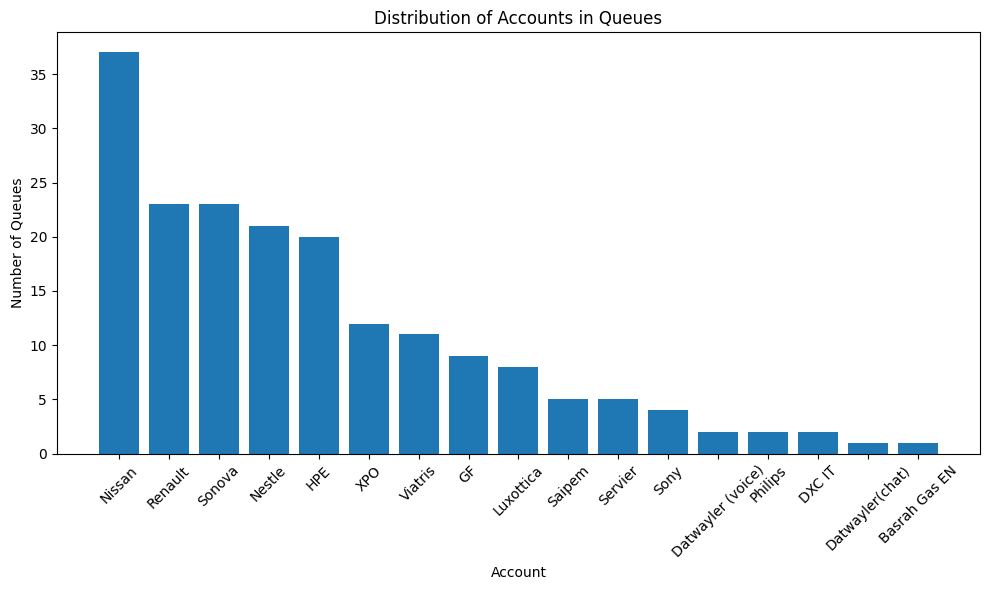

In [20]:

account_counts = Queues['account'].value_counts()

plt.figure(figsize=(10, 6))

bars = plt.bar(
    account_counts.index,
    account_counts.values
)

plt.title('Distribution of Accounts in Queues')
plt.xlabel('Account')
plt.ylabel('Number of Queues')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

This shows the distribution of accounts in the Queues dataset, indicating how many entries there are for each account.

In [21]:
Queues['Desk'].value_counts()

Desk
HPE SP          18
Renault FR      11
Nissan FR        8
Nissan IT        7
Nissan DU        6
                ..
GF_chat Ger      1
CH_AT_FR         1
CH_AT_GER        1
Renault Eng      1
Datwyler Ger     1
Name: count, Length: 76, dtype: int64

In [22]:
Queues.groupby('account')['Desk'].nunique().sort_values(ascending=False)

account
Renault              12
Viatris              11
Luxottica             8
Nissan                7
Sonova                7
GF                    5
Nestle                5
Servier               5
HPE                   3
Saipem                3
XPO                   2
DXC IT                2
Datwayler (voice)     2
Philips               1
Datwayler(chat)       1
Sony                  1
Basrah Gas EN         1
Name: Desk, dtype: int64

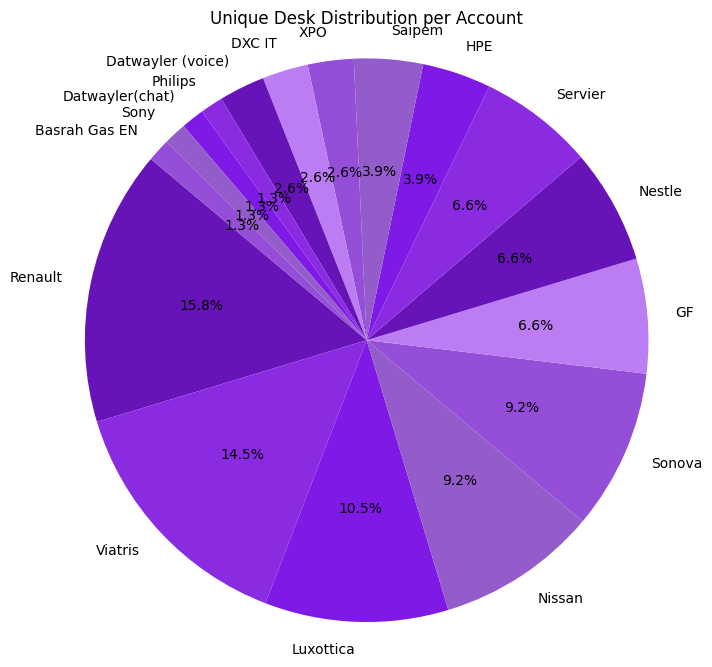

In [23]:
desk_counts = Queues.groupby('account')['Desk'].nunique().sort_values(ascending=False)

plt.figure(figsize=(8, 8))
plt.pie(desk_counts, 
        labels=desk_counts.index, 
        autopct='%1.1f%%', 
        startangle=140,
        colors=['#6614b8', '#8a2be2', '#7f19e6', '#945cca', '#944ed8', '#bd7df2'])
plt.title("Unique Desk Distribution per Account")
plt.axis('equal')  
plt.show()

Desk Distribution per Account

- High concentration in a few accounts
Renault (12) and Viatris (11) have the highest number of desks.
-> This indicates a more complex and segmented operational structure for these clients.

- Medium-complexity accounts
Luxottica (8), Nissan (7), and Sonova (7) also show significant multi-desk organization.
-> These accounts likely require more detailed and multi-level SLA monitoring.

- Moderate structure accounts
GF, Nestlé, and Servier (5 desks each) have a balanced level of segmentation.
-> Operational complexity exists but remains manageable.

- Low-complexity / centralized accounts
Philips, Sony, and Basrah Gas EN (1 desk each) are highly centralized.
-> Monitoring is simpler and operational variability is lower.

Important Customers:

Renault – 23 total queues, 12 active desks

Viatris – 11 total queues, 11 active desks

Luxottica – 8 total queues, 8 active desks

Nissan – 37 total queues, 7 active desks

Sonova – 23 total queues, 7 active desks

These accounts should get priority support and monitoring in DXC dashboards or SLA management because they represent the largest volume and engagement.

In [24]:
duplicates = Queues[Queues.duplicated()]
duplicates

,Queue name,Desk,account,Timeframe BH,Timeframe OOH,SLA answered,abd rate,autre SLA,Target Ans rate,Target Abd rate,Target autre SLA
60,Nestle DE CBA,Nestle DE,Nestle,30,30,SLA1(30sec),SLA1(45sec),SLA1(90sec),0.91,0.85,0.9
134,Sonova_Dutch_Other,Sonova DU,Sonova,60,60,SLA1,Abd4,NaN,0.8,0.05,NaN


In [25]:
Queues.duplicated().sum()

2

In [26]:
Queues.groupby('account')[['SLA answered', 'abd rate']].agg(lambda x: x.unique())

,SLA answered,abd rate
account,,
Basrah Gas EN,[SLA1],[Abd2]
DXC IT,[SLA2],[Abd2]
Datwayler (voice),[SLA1],[nan]
Datwayler(chat),[SLA1],[nan]
GF,[SLA2],[Abd3]
HPE,[SLA2],[Abd2]
Luxottica,[SLA3],[Abd5]
Nestle,[SLA1(30sec)],[SLA1(45sec)]
Nissan,[SLA1],[Abd1]


- Inconsistent Target Formats : 

Some targets are stored as percentages (e.g., 90%, 5%)

Some contain text values (e.g., 30 sec for Sony)

Some contain NA as text instead of true missing values

-> This creates datatype inconsistency and prevents direct numerical analysis.

- Missing Values

Basrah Gas EN → all target columns are NA

Saipem → Target Abd rate is NA

-> Some SLA configurations are incomplete.

* Duplicate Rows

Sonova_Dutch_Other appears twice (identical configuration)

In [27]:
import pandas as pd

All_Queues = pd.read_csv('../data/Telephony_Data.csv', sep=';')

print("First 5 rows:")
print(All_Queues.head())

First 5 rows:
  Queue,StartInterval,EndInterval,Contacts abandoned in 20 seconds,Contacts abandoned in 30 seconds,Contacts abandoned in 45 seconds,Contacts abandoned in 60 seconds,Contacts abandoned in 90 seconds,Contacts abandoned in 180 seconds,Contacts answered in 20 seconds,Contacts answered in 30 seconds,Contacts answered in 45 seconds,Contacts answered in 60 seconds,Contacts answered in 90 seconds,Contacts answered in 180 seconds,Service level 60 seconds,Service level 120 seconds,Agent interaction time,API contacts,API contacts handled,Average agent interaction time,Average customer hold time,Average handle time,Average queue abandon time,Average queue answer time,Callback contacts,Callback contacts handled,Contacts abandoned,Contacts handled incoming,Contacts handled outbound,Contacts queued,Contacts abandoned 40 seconds,Contacts answered 40 seconds
0  Benelux_Dutch_Queue,2024-05-02T08:00:00.000+02...                                                                               

In [28]:
print("Shape:", All_Queues.shape)

Shape: (248101, 1)


In [29]:
print(All_Queues.columns.tolist())

['Queue,StartInterval,EndInterval,Contacts abandoned in 20 seconds,Contacts abandoned in 30 seconds,Contacts abandoned in 45 seconds,Contacts abandoned in 60 seconds,Contacts abandoned in 90 seconds,Contacts abandoned in 180 seconds,Contacts answered in 20 seconds,Contacts answered in 30 seconds,Contacts answered in 45 seconds,Contacts answered in 60 seconds,Contacts answered in 90 seconds,Contacts answered in 180 seconds,Service level 60 seconds,Service level 120 seconds,Agent interaction time,API contacts,API contacts handled,Average agent interaction time,Average customer hold time,Average handle time,Average queue abandon time,Average queue answer time,Callback contacts,Callback contacts handled,Contacts abandoned,Contacts handled incoming,Contacts handled outbound,Contacts queued,Contacts abandoned 40 seconds,Contacts answered 40 seconds']


### Queue Data Dictionary

#### Column Descriptions

| Column Name | Description |
|:------------|:------------|
| **Queue** | Name of the service queue (client/language/service) |
| **StartDate** | Start date of the reporting interval |
| **StartTime** | Start time of the reporting interval (usually 30-minute windows) |
| **EndDate** | End date of the reporting interval |
| **EndTime** | End time of the reporting interval (usually 30-minute windows) |

#### Abandonment Metrics
| Column Name | Description |
|:------------|:------------|
| **Contacts abandoned in 20 seconds** | Number of customers who abandoned the queue before being answered within 20 seconds |
| **Contacts abandoned in 30 seconds** | Number of customers who abandoned the queue before being answered within 30 seconds |
| **Contacts abandoned in 40 seconds** | Number of customers who abandoned the queue before being answered within 40 seconds |
| **Contacts abandoned in 45 seconds** | Number of customers who abandoned the queue before being answered within 45 seconds |
| **Contacts abandoned in 60 seconds** | Number of customers who abandoned the queue before being answered within 60 seconds |
| **Contacts abandoned in 180 seconds** | Number of customers who abandoned the queue before being answered within 180 seconds |
| **Contacts abandoned** | Total number of abandoned contacts (regardless of waiting time) |

#### Answered Metrics
| Column Name | Description |
|:------------|:------------|
| **Contacts answered in 20 seconds** | Number of contacts answered within 20 seconds |
| **Contacts answered in 30 seconds** | Number of contacts answered within 30 seconds |
| **Contacts answered in 40 seconds** | Number of contacts answered within 40 seconds |
| **Contacts answered in 45 seconds** | Number of contacts answered within 45 seconds |
| **Contacts answered in 60 seconds** | Number of contacts answered within 60 seconds |
| **Contacts answered in 180 seconds** | Number of contacts answered within 180 seconds |

#### Service Level Performance
| Column Name | Description |
|:------------|:------------|
| **Service level 60 seconds** | Percentage of contacts answered within 60 seconds (key SLA indicator) |
| **Service level 120 seconds** | Percentage of contacts answered within 120 seconds (key SLA indicator) |

#### Agent Performance Metrics
| Column Name | Description |
|:------------|:------------|
| **Agent interaction time** | Total time agents spent handling contacts (in seconds) |
| **Average agent interaction time** | Average interaction duration per contact |
| **Average handle time (AHT)** | Average total time per contact |

#### Queue & Waiting Metrics
| Column Name | Description |
|:------------|:------------|
| **Average queue answer time** | Average waiting time before a contact was answered |
| **Average queue abandon time** | Average waiting time before a contact abandoned the queue |
| **Customer hold time** | Total time customers spent on hold |

#### Volume Metrics
| Column Name | Description |
|:------------|:------------|
| **Contacts handled incoming** | Number of incoming contacts handled |
| **Contacts handled outbound** | Number of outbound contacts handled |
| **Contacts queued** | Number of contacts that entered the queue |

#### Digital & Callback Metrics
| Column Name | Description |
|:------------|:------------|
| **API contacts** | Number of contacts created via chat/API system |
| **API contacts handled** | Number of API/chat contacts that were handled |
| **Callback contacts** | Number of callback requests received |
| **Callback contacts handled** | Number of callbacks successfully completed |

In [30]:
duplicate = All_Queues[All_Queues.duplicated()]
duplicate
duplicate_count = All_Queues.duplicated().sum()

In [31]:
All_Queues.isnull().sum()

Queue,StartInterval,EndInterval,Contacts abandoned in 20 seconds,Contacts abandoned in 30 seconds,Contacts abandoned in 45 seconds,Contacts abandoned in 60 seconds,Contacts abandoned in 90 seconds,Contacts abandoned in 180 seconds,Contacts answered in 20 seconds,Contacts answered in 30 seconds,Contacts answered in 45 seconds,Contacts answered in 60 seconds,Contacts answered in 90 seconds,Contacts answered in 180 seconds,Service level 60 seconds,Service level 120 seconds,Agent interaction time,API contacts,API contacts handled,Average agent interaction time,Average customer hold time,Average handle time,Average queue abandon time,Average queue answer time,Callback contacts,Callback contacts handled,Contacts abandoned,Contacts handled incoming,Contacts handled outbound,Contacts queued,Contacts abandoned 40 seconds,Contacts answered 40 seconds    0
dtype: int64

In [32]:
print("\nData types:")
print(All_Queues.dtypes)


Data types:
Queue,StartInterval,EndInterval,Contacts abandoned in 20 seconds,Contacts abandoned in 30 seconds,Contacts abandoned in 45 seconds,Contacts abandoned in 60 seconds,Contacts abandoned in 90 seconds,Contacts abandoned in 180 seconds,Contacts answered in 20 seconds,Contacts answered in 30 seconds,Contacts answered in 45 seconds,Contacts answered in 60 seconds,Contacts answered in 90 seconds,Contacts answered in 180 seconds,Service level 60 seconds,Service level 120 seconds,Agent interaction time,API contacts,API contacts handled,Average agent interaction time,Average customer hold time,Average handle time,Average queue abandon time,Average queue answer time,Callback contacts,Callback contacts handled,Contacts abandoned,Contacts handled incoming,Contacts handled outbound,Contacts queued,Contacts abandoned 40 seconds,Contacts answered 40 seconds    object
dtype: object


In [33]:
print("\nSummary statistics for numerical columns:")
print(All_Queues.describe())

print("\nSummary for object (categorical) columns:")
print(All_Queues.describe(include='object'))


Summary statistics for numerical columns:
       Queue,StartInterval,EndInterval,Contacts abandoned in 20 seconds,Contacts abandoned in 30 seconds,Contacts abandoned in 45 seconds,Contacts abandoned in 60 seconds,Contacts abandoned in 90 seconds,Contacts abandoned in 180 seconds,Contacts answered in 20 seconds,Contacts answered in 30 seconds,Contacts answered in 45 seconds,Contacts answered in 60 seconds,Contacts answered in 90 seconds,Contacts answered in 180 seconds,Service level 60 seconds,Service level 120 seconds,Agent interaction time,API contacts,API contacts handled,Average agent interaction time,Average customer hold time,Average handle time,Average queue abandon time,Average queue answer time,Callback contacts,Callback contacts handled,Contacts abandoned,Contacts handled incoming,Contacts handled outbound,Contacts queued,Contacts abandoned 40 seconds,Contacts answered 40 seconds
count                                              248101                                        

In [34]:
print("\nUnique values per column (top 5 for categorical):")
for col in All_Queues.select_dtypes(include='object'):
    print(f"{col}: {All_Queues[col].nunique()} unique values - {All_Queues[col].value_counts().head()}")


Unique values per column (top 5 for categorical):
Queue,StartInterval,EndInterval,Contacts abandoned in 20 seconds,Contacts abandoned in 30 seconds,Contacts abandoned in 45 seconds,Contacts abandoned in 60 seconds,Contacts abandoned in 90 seconds,Contacts abandoned in 180 seconds,Contacts answered in 20 seconds,Contacts answered in 30 seconds,Contacts answered in 45 seconds,Contacts answered in 60 seconds,Contacts answered in 90 seconds,Contacts answered in 180 seconds,Service level 60 seconds,Service level 120 seconds,Agent interaction time,API contacts,API contacts handled,Average agent interaction time,Average customer hold time,Average handle time,Average queue abandon time,Average queue answer time,Callback contacts,Callback contacts handled,Contacts abandoned,Contacts handled incoming,Contacts handled outbound,Contacts queued,Contacts abandoned 40 seconds,Contacts answered 40 seconds: 244515 unique values - Queue,StartInterval,EndInterval,Contacts abandoned in 20 seconds,Contact

In [35]:
numerical_cols = All_Queues.select_dtypes(include='number').columns

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(All_Queues[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
    plt.show()

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=All_Queues[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [36]:
print(All_Queues.columns)

Index(['Queue,StartInterval,EndInterval,Contacts abandoned in 20 seconds,Contacts abandoned in 30 seconds,Contacts abandoned in 45 seconds,Contacts abandoned in 60 seconds,Contacts abandoned in 90 seconds,Contacts abandoned in 180 seconds,Contacts answered in 20 seconds,Contacts answered in 30 seconds,Contacts answered in 45 seconds,Contacts answered in 60 seconds,Contacts answered in 90 seconds,Contacts answered in 180 seconds,Service level 60 seconds,Service level 120 seconds,Agent interaction time,API contacts,API contacts handled,Average agent interaction time,Average customer hold time,Average handle time,Average queue abandon time,Average queue answer time,Callback contacts,Callback contacts handled,Contacts abandoned,Contacts handled incoming,Contacts handled outbound,Contacts queued,Contacts abandoned 40 seconds,Contacts answered 40 seconds'], dtype='object')


In [37]:
All_Queues.columns = All_Queues.columns.str.strip()

All_Queues['StartInterval'] = pd.to_datetime(All_Queues['StartInterval'], errors='coerce')
All_Queues['EndInterval'] = pd.to_datetime(All_Queues['EndInterval'], errors='coerce')

first_date = All_Queues['StartInterval'].min()
last_date = All_Queues['EndInterval'].max()

print("First date:", first_date)
print("Last date:", last_date)

days_between = (last_date - first_date).days
print("Number of days between first and last date:", days_between)

KeyError: 'StartInterval'

In [ ]:
duplicates = Metrics[Metrics.duplicated()]
print("\nNumber of duplicate rows:", duplicates.shape[0])


Number of duplicate rows: 0


In [ ]:
if 'StartInterval' in All_Queues.columns:
    All_Queues['StartInterval'] = pd.to_datetime(All_Queues['StartInterval'], errors='coerce')
    
    first_date = All_Queues['StartInterval'].min()
    last_date = All_Queues['StartInterval'].max()
    
    print("\nDate range for StartInterval:")
    print(first_date, "to", last_date)
    
    days_between = (last_date - first_date).days
    print("Number of days between first and last date:", days_between)


Date range for StartInterval:
2026-02-01 00:30:00+01:00 to 2026-02-28 22:00:00+01:00
Number of days between first and last date: 27


In [ ]:
print("Shape:", All_Queues.shape)
print("\nColumns:", All_Queues.columns.tolist())
print("\nData types:\n", All_Queues.dtypes)

Shape: (11672, 34)

Columns: ['Queue', 'StartInterval', 'EndInterval', 'Contacts abandoned in 20 seconds', 'Contacts abandoned in 30 seconds', 'Contacts abandoned in 45 seconds', 'Contacts abandoned in 60 seconds', 'Contacts abandoned in 90 seconds', 'Contacts abandoned in 180 seconds', 'Contacts answered in 20 seconds', 'Contacts answered in 30 seconds', 'Contacts answered in 45 seconds', 'Contacts answered in 60 seconds', 'Contacts answered in 90 seconds', 'Contacts answered in 180 seconds', 'Service level 60 seconds', 'Service level 120 seconds', 'Agent interaction time', 'API contacts', 'API contacts handled', 'Average agent interaction time', 'Average customer hold time', 'Average handle time', 'Average queue abandon time', 'Average queue answer time', 'Callback contacts', 'Callback contacts handled', 'Contacts abandoned', 'Contacts handled incoming', 'Contacts handled outbound', 'Contacts put on hold', 'Contacts queued', 'Contacts abandoned 40 seconds', 'Contacts answered 40 seco

In [ ]:
duplicates = All_Queues[All_Queues.duplicated()]
print("\nNumber of duplicate rows:", duplicates.shape[0])


Number of duplicate rows: 0


In [ ]:
print("\nSummary statistics for numerical columns:\n", All_Queues.describe())
print("\nSummary for categorical columns:\n", All_Queues.describe(include='object'))


Summary statistics for numerical columns:
        Contacts abandoned in 20 seconds  Contacts abandoned in 30 seconds  \
count                        153.000000                        167.000000   
mean                           1.058824                          1.059880   
std                            0.236067                          0.237978   
min                            1.000000                          1.000000   
25%                            1.000000                          1.000000   
50%                            1.000000                          1.000000   
75%                            1.000000                          1.000000   
max                            2.000000                          2.000000   

       Contacts abandoned in 45 seconds  Contacts abandoned in 60 seconds  \
count                        190.000000                        206.000000   
mean                           1.073684                          1.097087   
std                            

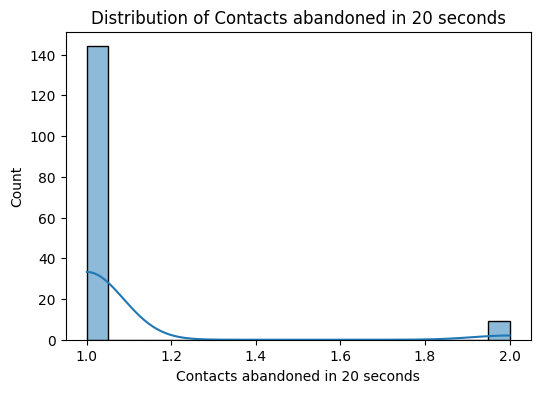

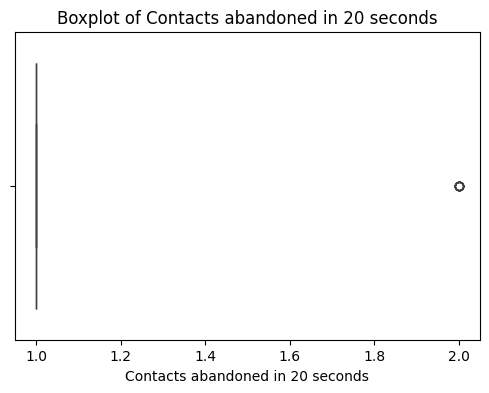

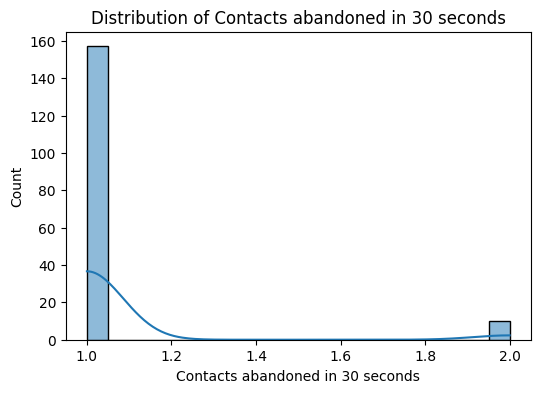

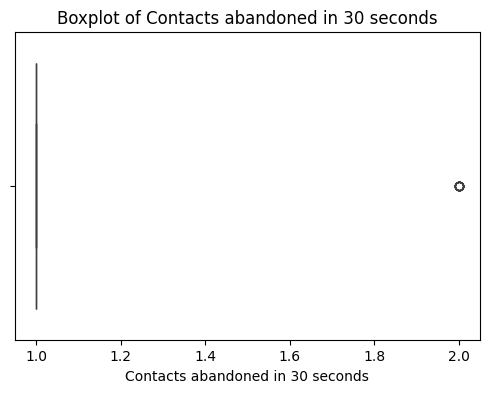

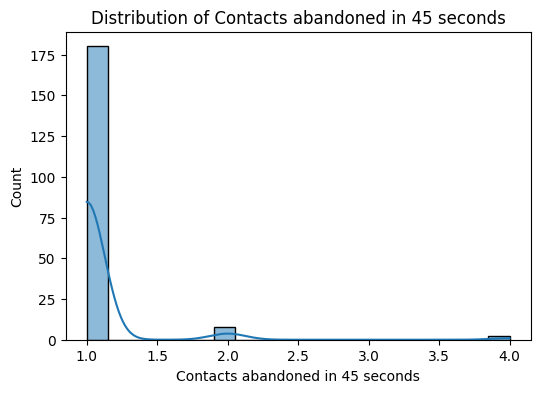

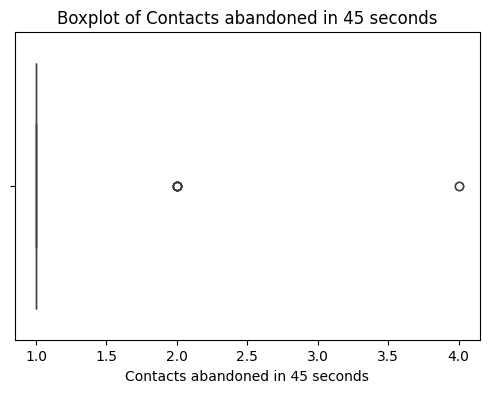

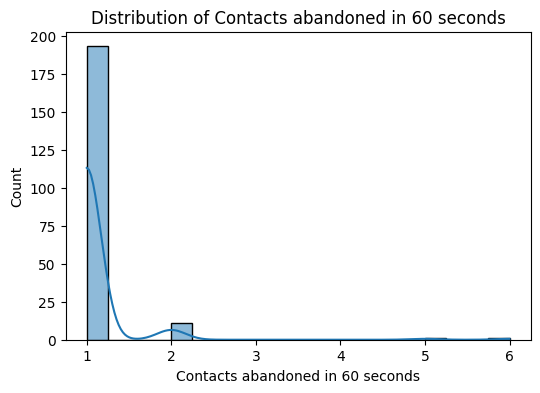

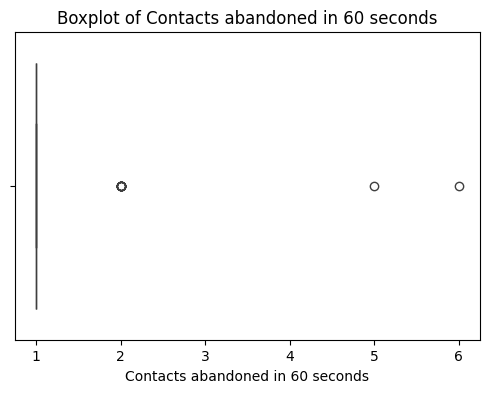

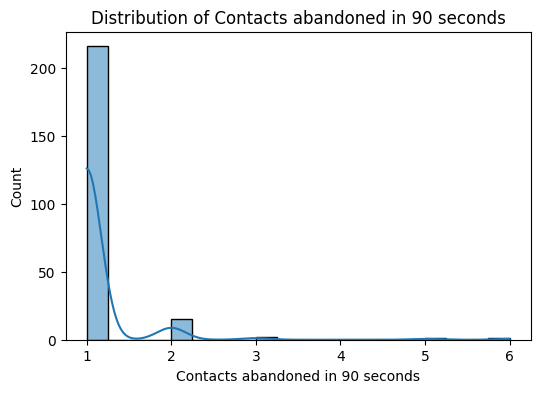

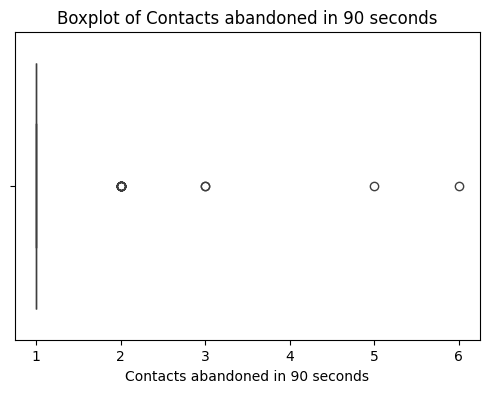

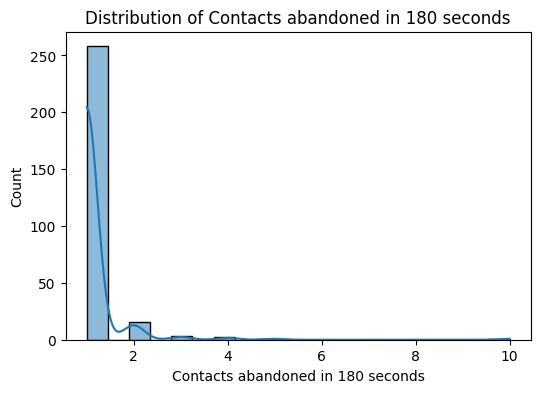

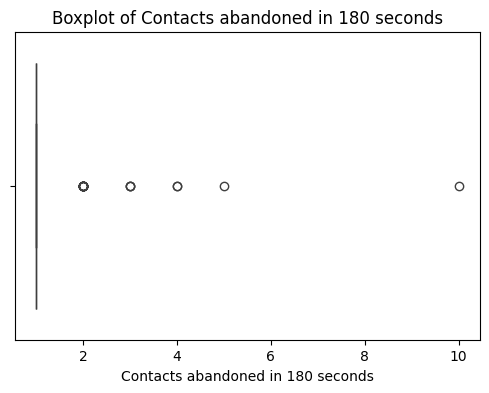

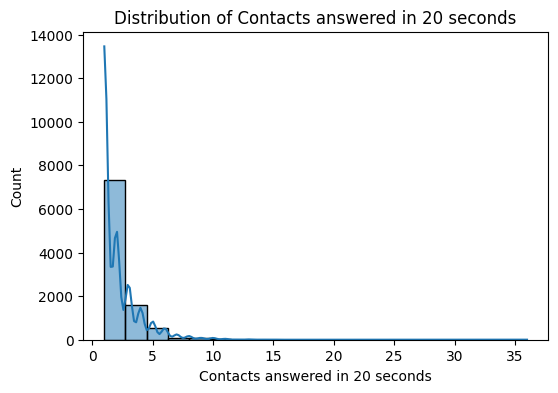

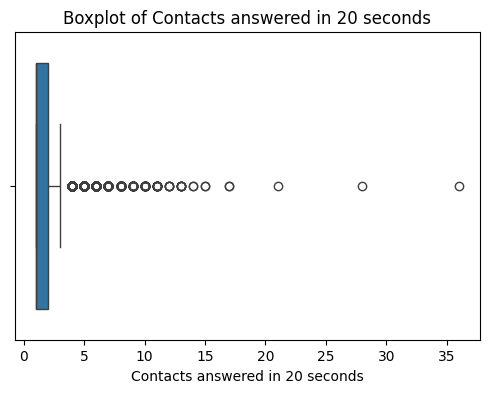

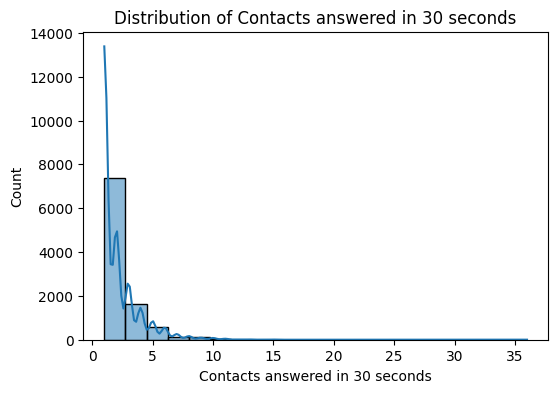

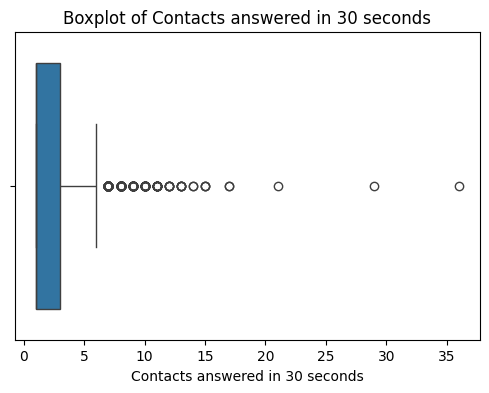

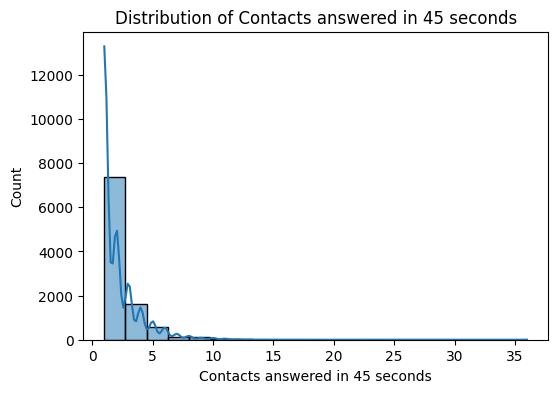

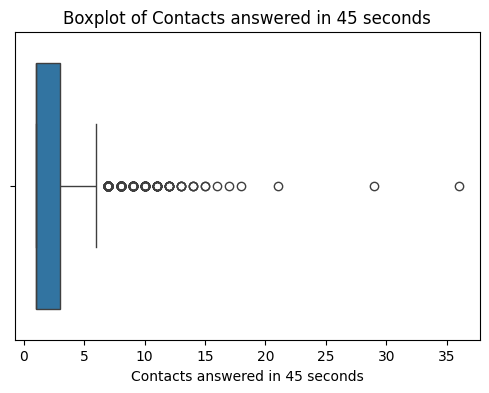

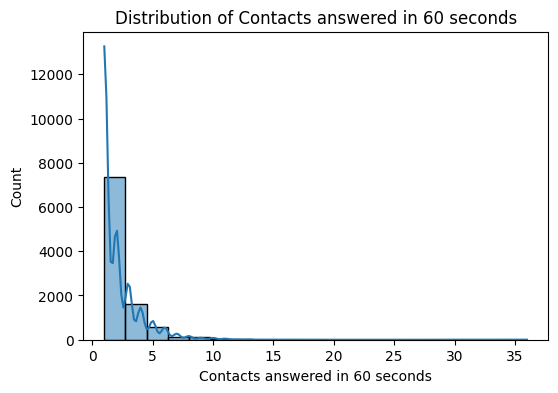

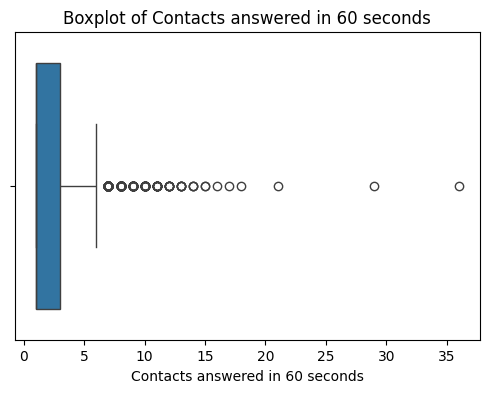

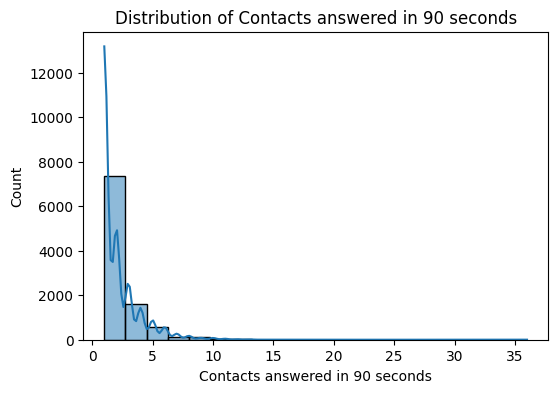

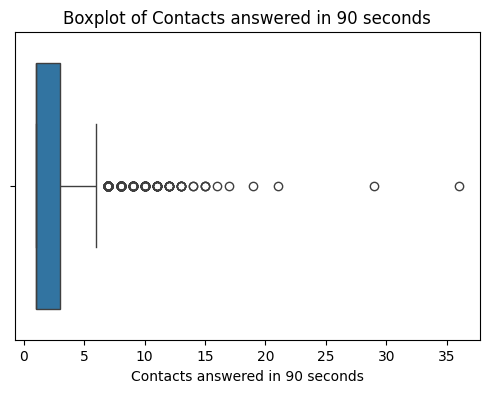

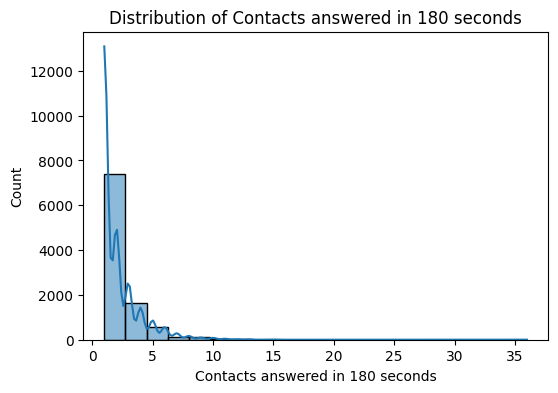

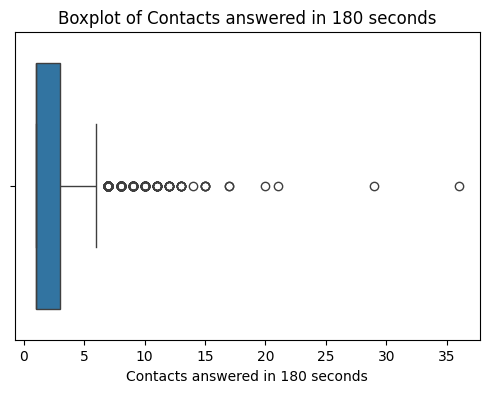

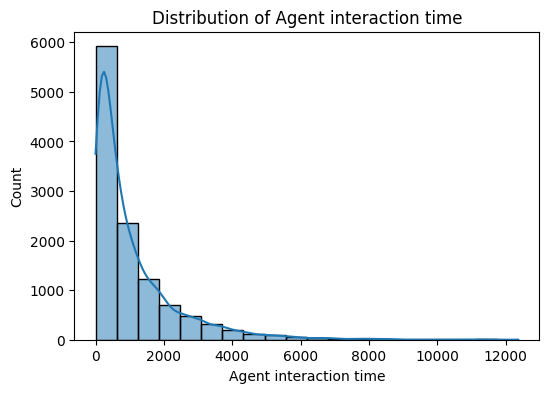

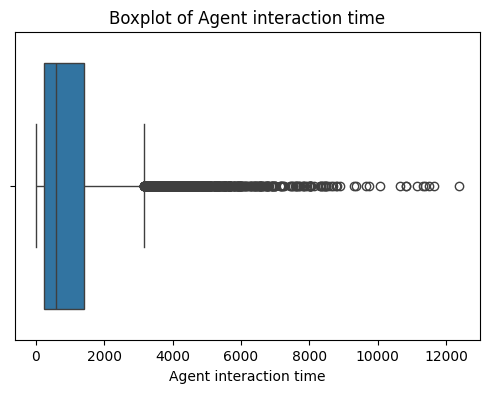

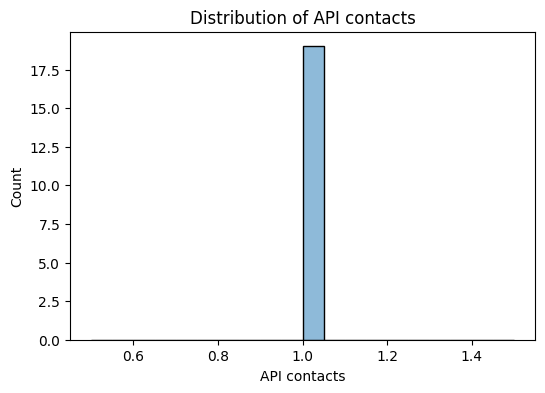

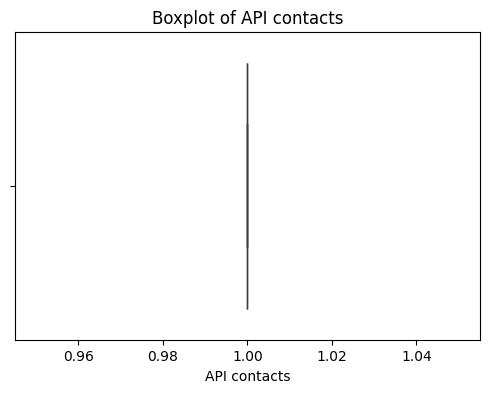

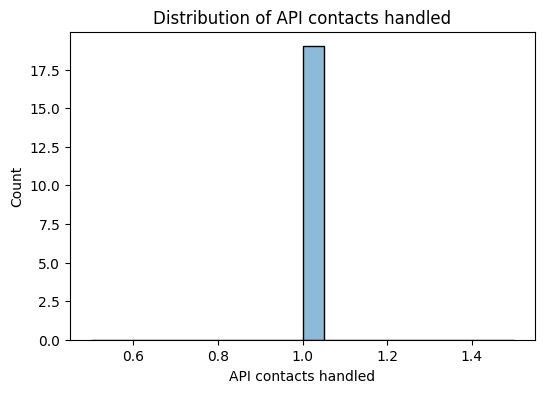

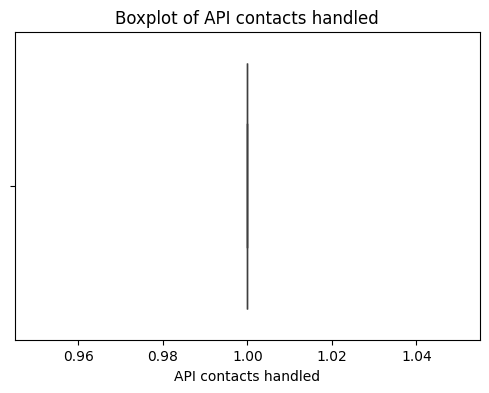

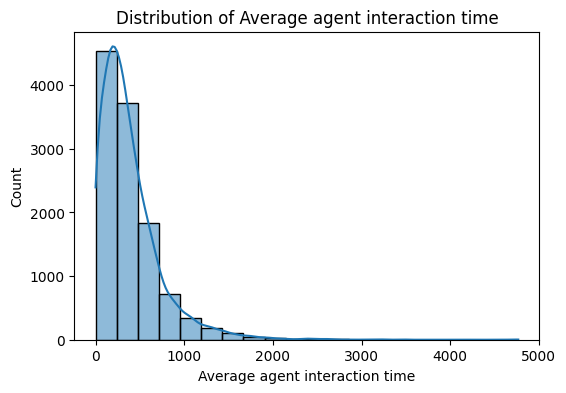

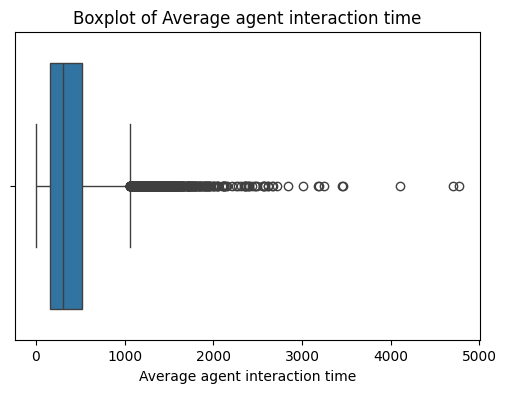

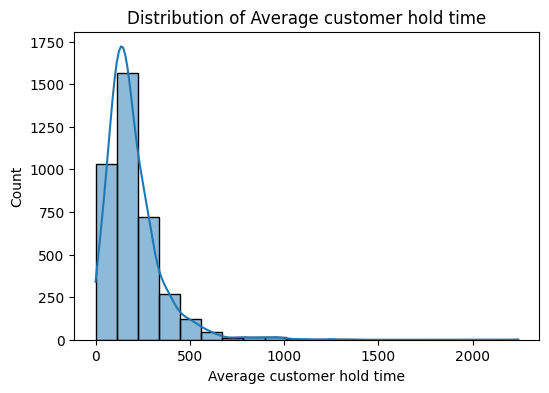

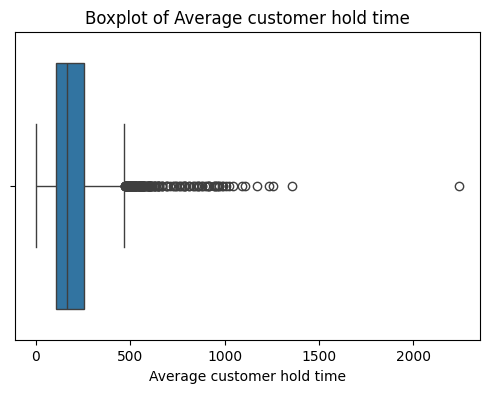

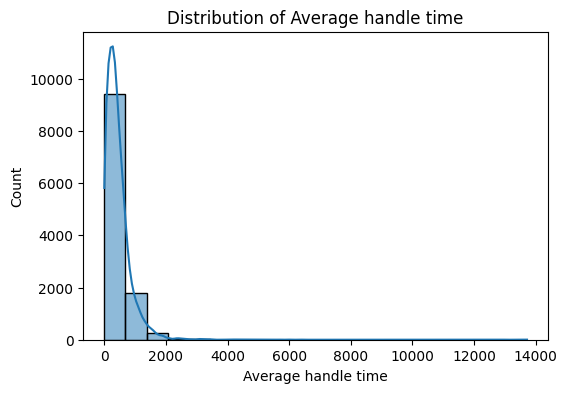

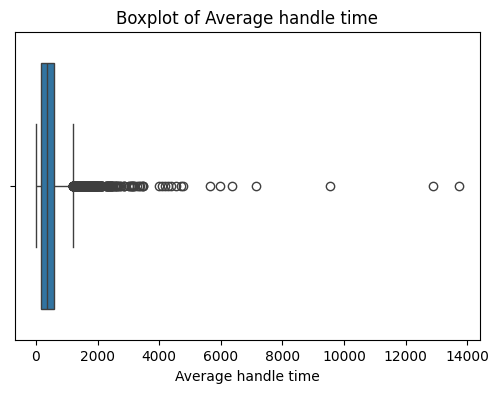

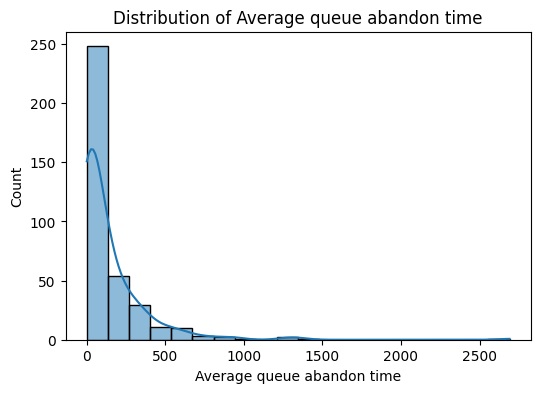

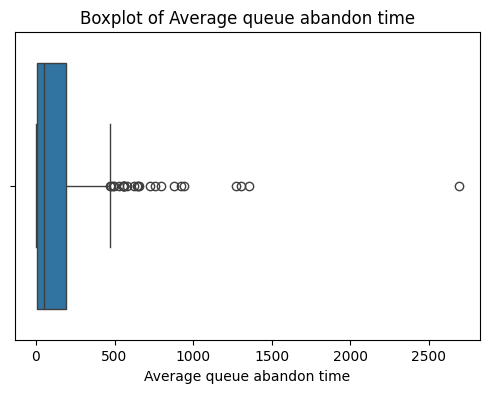

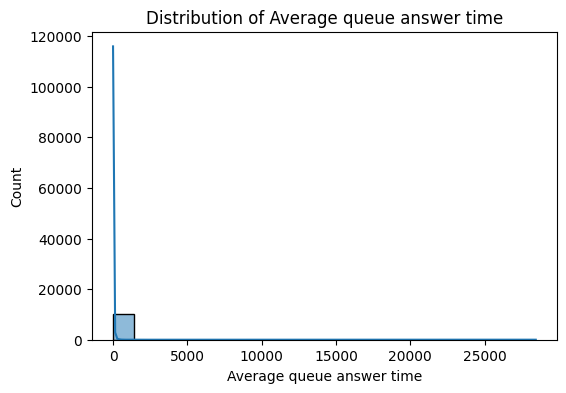

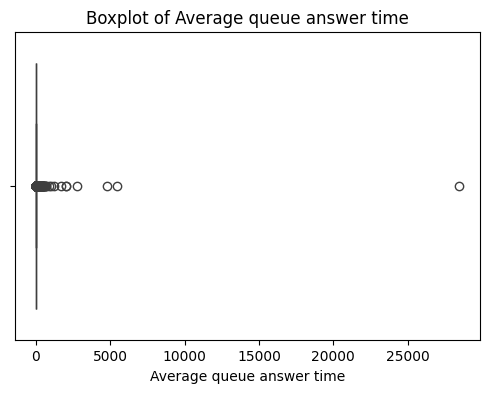

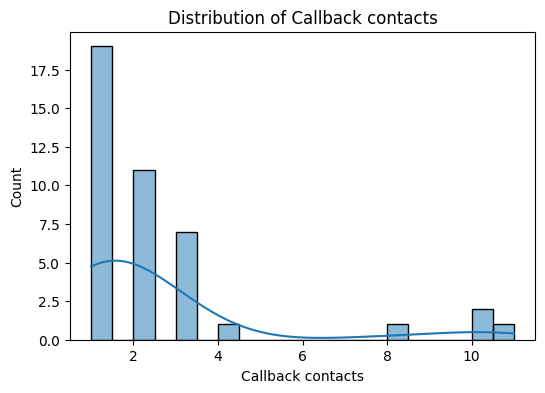

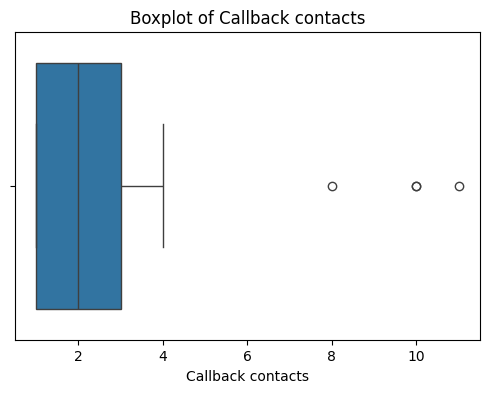

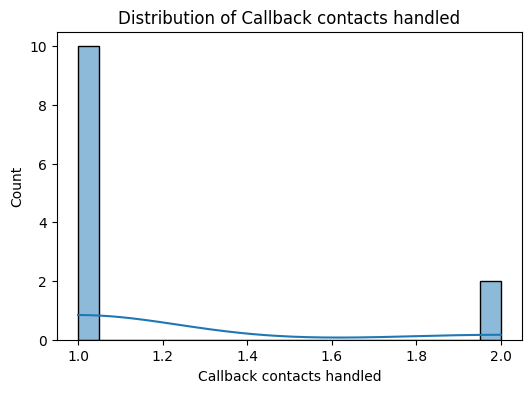

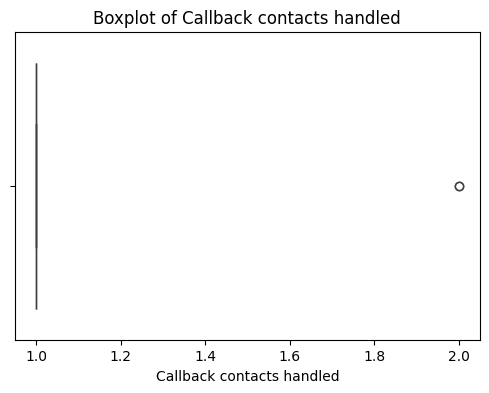

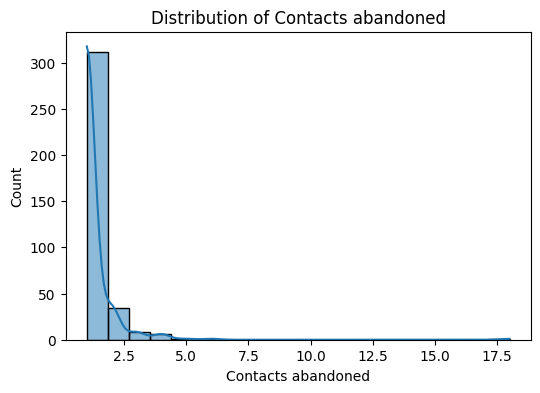

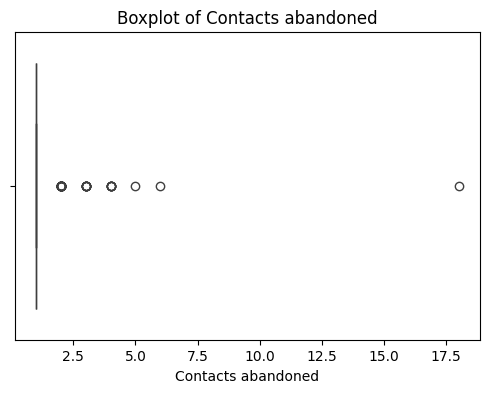

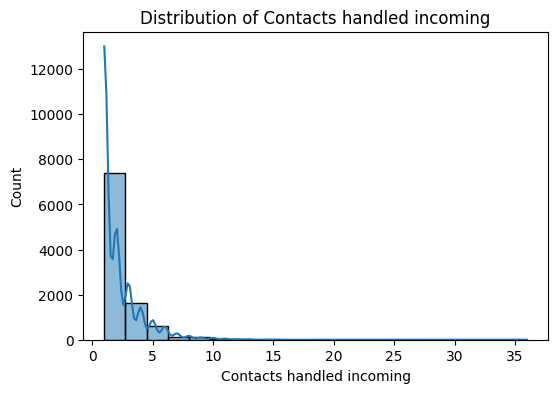

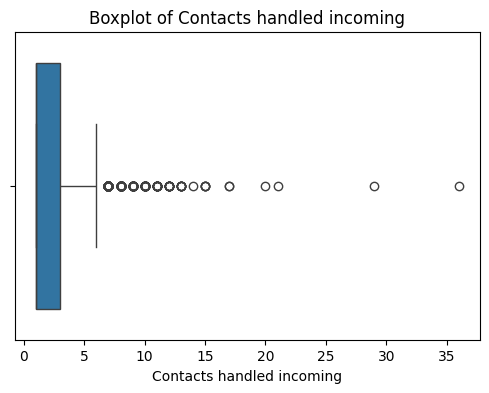

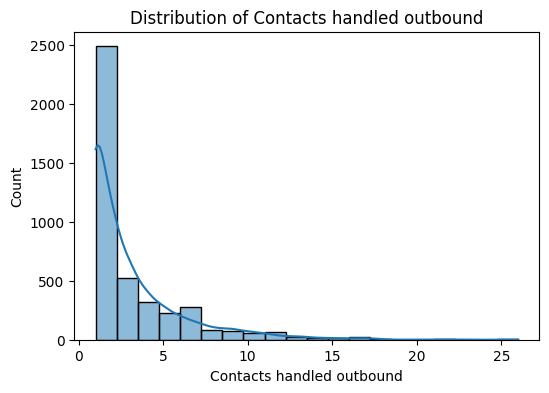

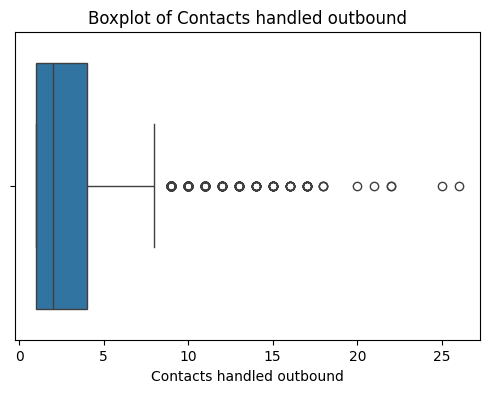

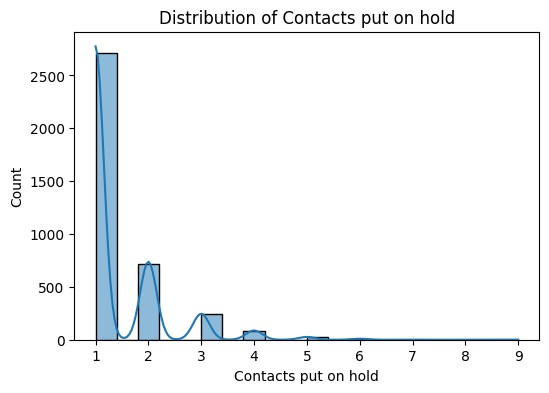

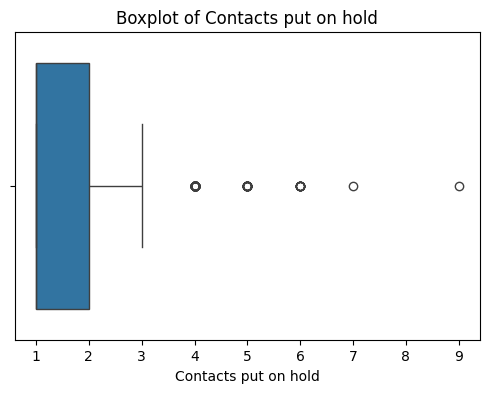

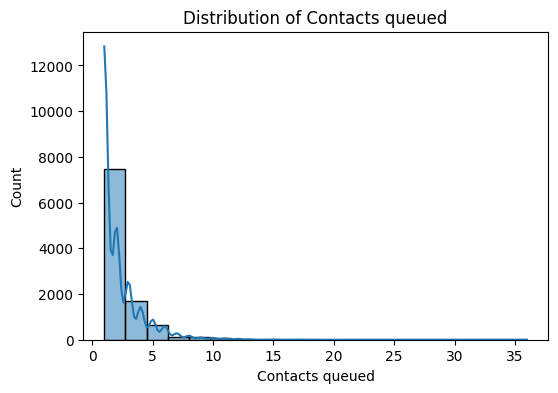

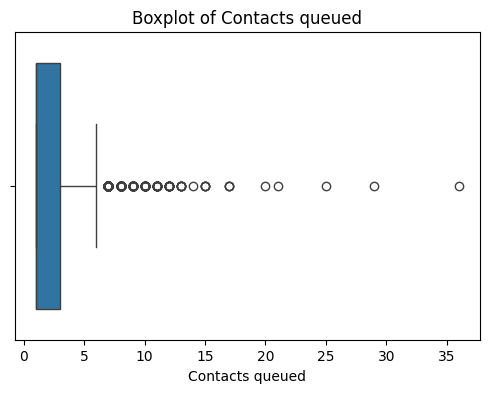

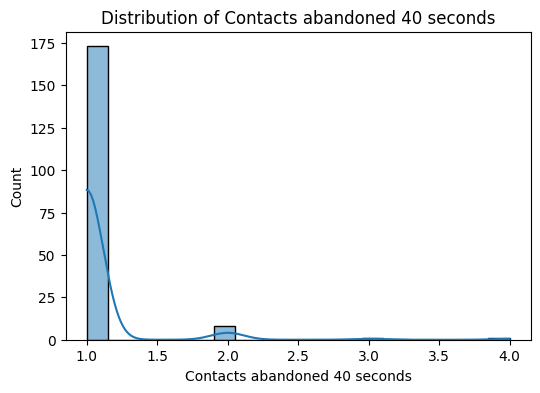

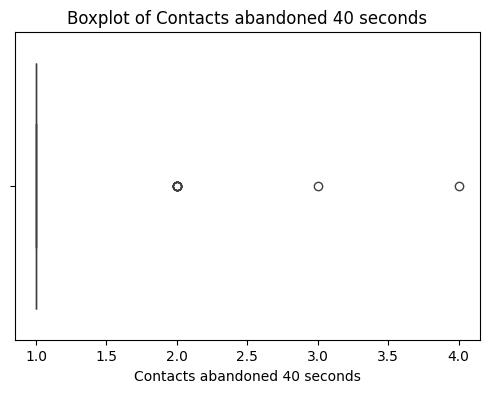

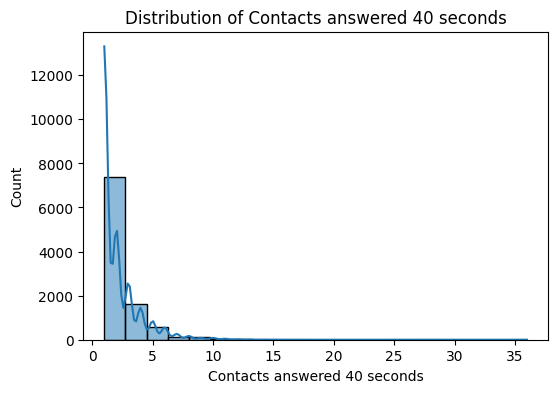

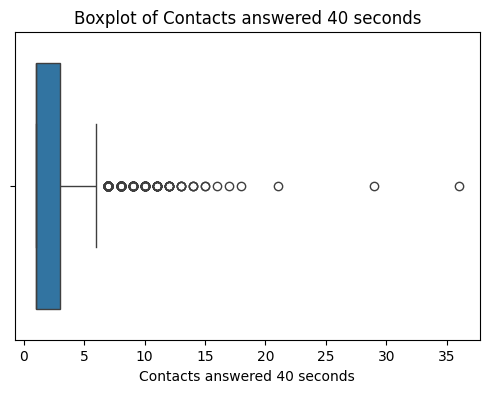

In [ ]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(All_Queues[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
    plt.show()
    
    plt.figure(figsize=(6,4))
    sns.boxplot(x=All_Queues[col])
    plt.title(f"Boxplot of {col}")
    plt.show()